In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
from corner import corner
from getdist import plots
import seaborn as sns
import scienceplots


import sys
sys.path.append("../")

from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

In [3]:
def read_void_stats(profile):
    fname = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/void_stats_{profile}.hdf5"

    with File(fname, 'r') as f:
        sizes, rLG, r_grid, phi_grid = [f[f"grid/{x}"][...]
                                        for x in ["sizes", "rLG", "r_grid", "phi_grid"]]
        r_bulk, enclosed_density, monopole, bulk_flow = [
            f[f"void_stats/{x}"][...]
            for x in ["r", "enclosed_density", "monopole", "bulk_flow"]]

    return sizes, rLG, r_grid, phi_grid, r_bulk, enclosed_density, monopole, bulk_flow


def read_void_stats_per_sample(fname):
    with File(fname.replace(".hdf5", "_stats.hdf5"), 'r') as f:
        r = f["void_stats/r"][...]
        Vext = f["void_stats/Vext"][...]
        Vmono = f["void_stats/monopole"][...]
        rho = f["void_stats/enclosed_density"][...]
        Vbulk_void = f["void_stats/bulk_flow"][...]
    
    Vtot = Vbulk_void + Vext[:, None, :]

    Vbulk_mag, Vmag_l, Vmag_b= cartesian_to_radec(
        Vtot[..., 0], Vtot[..., 1], Vtot[..., 2])
    Vmag_l, Vmag_b = csiborgtools.radec_to_galactic(Vmag_l, Vmag_b)

    Vbulk_void = np.linalg.norm(Vbulk_void, axis=-1)
    Vext = np.linalg.norm(Vext, axis=-1)

    return r, rho, Vmono, Vbulk_mag, Vbulk_void, Vext, Vmag_l, Vmag_b


def fiducial_bulk_flow_sergij(profile):
    if profile == "exp":
        r_LG = 36
        v_void = 688.56
    elif profile == "gauss":
        r_LG = 39
        v_void = 734.92
    else:
        raise ValueError(f"Profile `{profile}` not recognized.")

    sizes_grid, rLG_grid, r_grid, phi_grid, r_bulk, enclosed_density, monopole, bulk_flow = read_void_stats(profile)

    k = np.argmin(np.abs(sizes_grid - 1))
    # Pointing in the Watkins direction.
    v_void = -v_void * np.asarray([-0.4035093, 0.01363162, -0.91487399])
    Vmag = np.linalg.norm(bulk_flow[k, r_LG] + v_void[None, :], axis=-1)

    rho = enclosed_density[k, r_LG]
    vmono = monopole[k, r_LG]

    return r_bulk, rho, vmono, Vmag


### Quick checks

In [5]:
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers_stats.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoid_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_remove_CF4_outliers.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_coarse_remove_CF4_outliers.hdf5"



r, rho, Vmono, Vbulk_mag, Vbulk_void, Vext, Vmag_l, Vmag_b = read_void_stats_per_sample(fname)

/mnt/users/rstiskalek/csiborgtools/notebooks/flow/paper_void/../reconstruction_comparison.py:34: RuntimeWarning: invalid value encountered in divide
  dec = np.arcsin(z / d)


/mnt/users/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


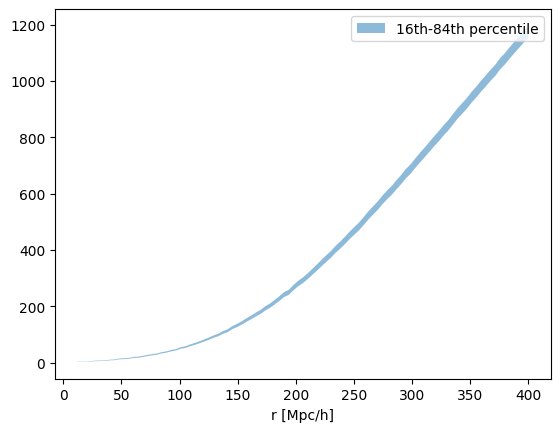

In [6]:
plt.figure()
ylow, ymed, yhigh = np.nanpercentile(Vmono, [16, 50, 84], axis=0)
plt.fill_between(r, ylow, yhigh, alpha=0.5, label="16th-84th percentile")
plt.xlabel("r [Mpc/h]")
# plt.xlim(0, 150)
# plt.ylabel("V_l [km/s]")
plt.legend()
plt.show()

Read in samples are:
 ['Vmag', 'l', 'b', 'rLG', 'sigma_v', 'aTFR_CF4_TFR_w1', 'bTFR_CF4_TFR_w1', 'cTFR_CF4_TFR_w1', 'beta']


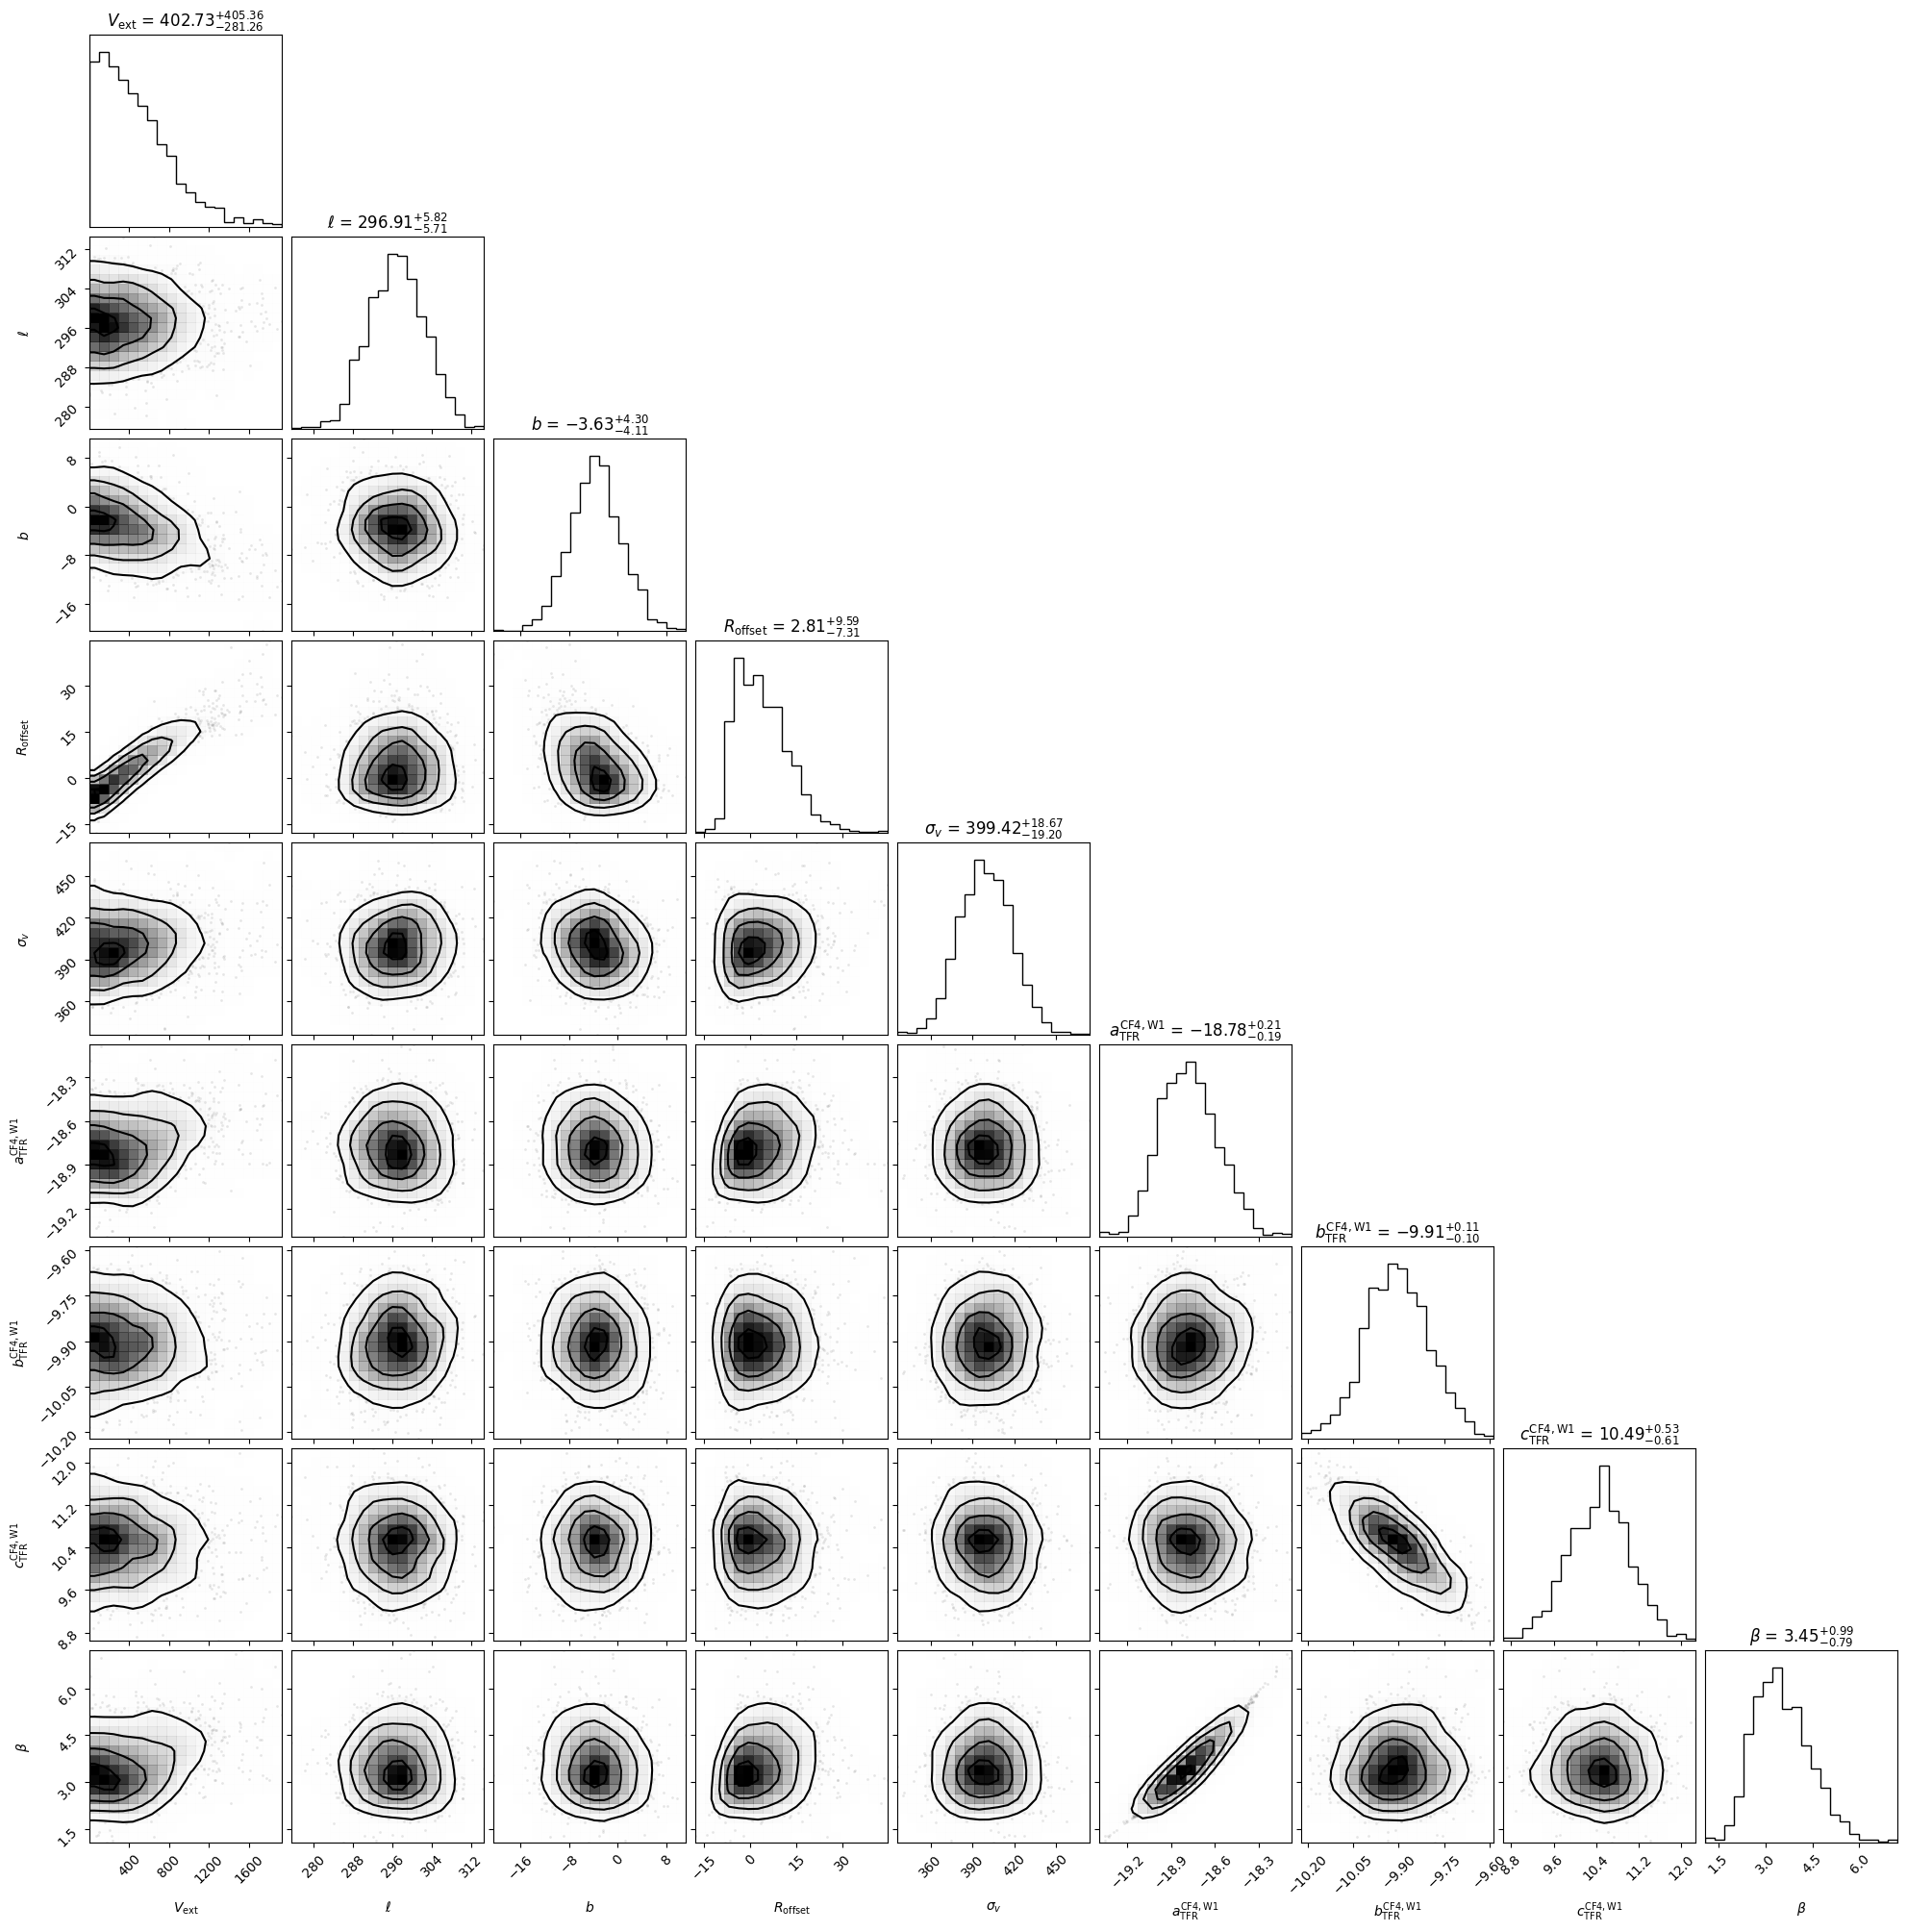

In [ ]:
# Degeneracy example in mock:
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_gauss_IndranilVoidTFRMock_0_mike_zcmb_max_0.05_sample_beta_which_void_size_run_zoom.hdf5"

# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5"


# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_no_field_300_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5"

fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoid_gauss_CF4_TFR_w1_mike_zcmb_max_0.065_sample_beta_remove_CF4_outliers.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_mb_CF4_TFR_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5"


# samples = get_some_samples(fname, ["Vext", "rLG", ])
samples = get_some_samples(fname, ["Vext", "rLG", "void_size", 'sigma_v', 'aTFR', 'bTFR', 'cTFR'])

print("Read in samples are:\n", list(samples.keys()))
data, labels, keys = samples_for_corner(samples)

fig = corner(data, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1)

# fig.savefig("../../plots/exp_test.png", dpi=450)
fig.show()

Read in samples are:
 ['Vmag', 'l', 'b', 'rLG', 'void_size', 'sigma_v', 'aTFR_CF4_TFR_w1', 'bTFR_CF4_TFR_w1', 'cTFR_CF4_TFR_w1', 'beta']


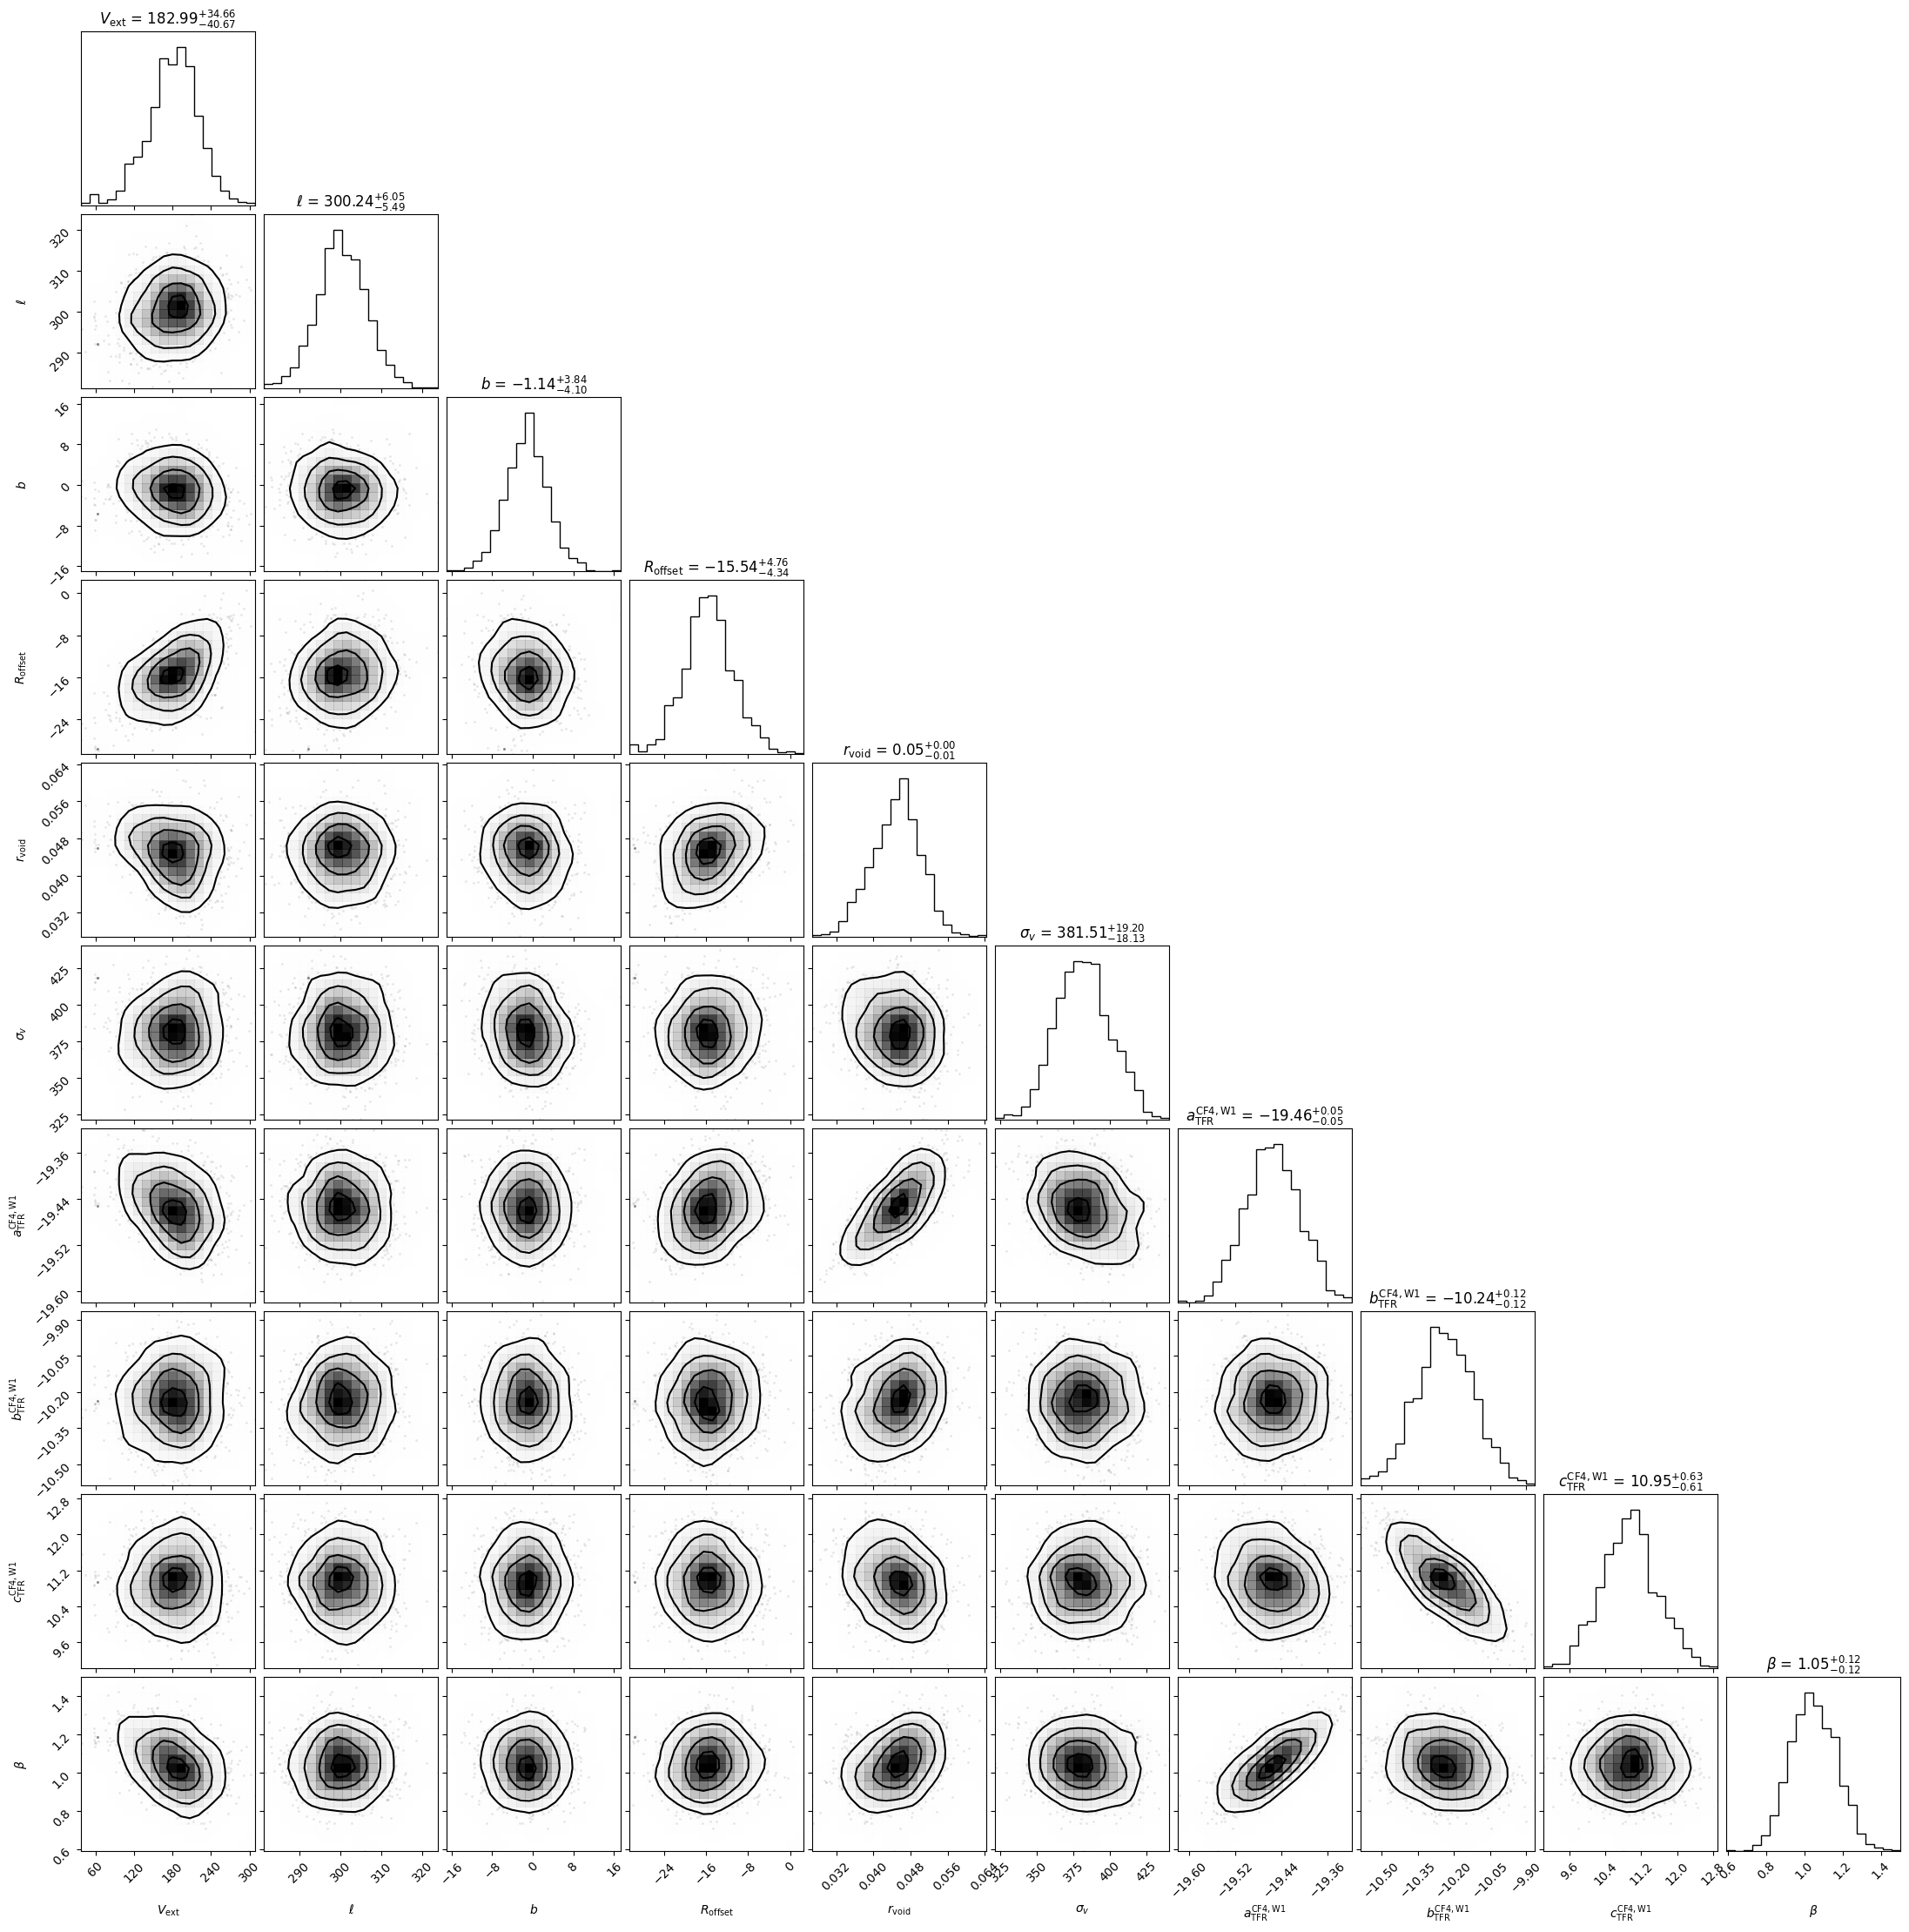

In [9]:
fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoidSizeVar_gauss_CF4_TFR_w1_mike_zcmb_max_0.065_sample_beta_which_void_size_run_zoom_remove_CF4_outliers.hdf5"
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoid_gauss_CF4_TFR_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5"
samples = get_some_samples(fname, ["Vext", "rLG", "void_size", 'sigma_v', 'aTFR', 'bTFR', 'cTFR', 'beta'])

print("Read in samples are:\n", list(samples.keys()))
data, labels, keys = samples_for_corner(samples)

# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoid_gauss_CF4_TFR_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5"
# samples = get_some_samples(fname, ["Vext", "rLG", "void_size", 'sigma_v', 'aTFR', 'bTFR', 'cTFR'])
# data2, __, __ = samples_for_corner(samples)



fig = corner(data, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1, hist_kwargs={"density": True},)
# corner(data2, fig=fig, labels=labels, show_titles=True,
#        title_kwargs={"fontsize": 12}, smooth=1,
    #    color='red', label_kwargs={"fontsize": 14}, hist_kwargs={"density": True})

# fig.savefig("../../plots/exp_test.png", dpi=450)
fig.savefig("void_test.png", dpi=450)
fig.show()

### Sergij's $\chi^2$ grid

In [8]:
kind = "MB"
fpath = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_{kind}profileresolution_3501x601.dat"  # noqa

print(f"Reading the chi2 grid from `{fpath}`.")
data = np.genfromtxt(fpath)

i, j = np.unravel_index(np.argmin(data), data.shape)
print(f"Minimum chi2: {data[i, j]} at Roffset_index = {i}, Vext_index = {j}.")

Reading the chi2 grid from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_MBprofileresolution_3501x601.dat`.
Minimum chi2: 1.456 at Roffset_index = 702, Vext_index = 214.


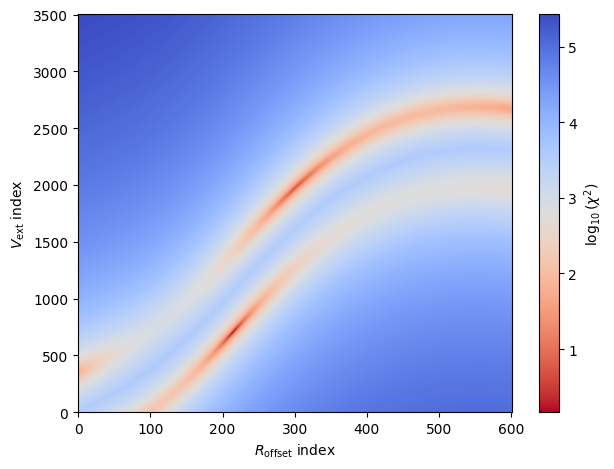

In [9]:
plt.figure()
plt.imshow(np.log10(data), origin="lower", aspect="auto", cmap="coolwarm_r")
plt.colorbar(label=r"$\log_{10}(\chi^2)$")
plt.xlabel(r"$R_{\rm offset}$ index")
plt.ylabel(r"$V_{\rm ext}$ index")
plt.tight_layout()
# plt.savefig("test.pdf", dpi=450)
plt.show()

Read in samples are:
 ['rLG']


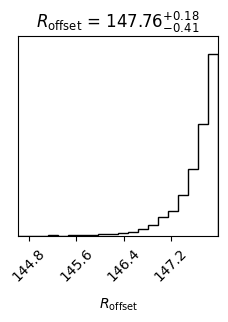

In [10]:
fname = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_{kind}profileresolution_3501x601_samples.hdf5"
samples = get_some_samples(fname, ["rLG", "Vmag"])
print("Read in samples are:\n", list(samples.keys()))

data, labels, keys = samples_for_corner(samples)
fig = corner(data, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1)

fig.show()

## Paper plots

### Fiducial analysis

#### Posterior ($\beta = 1$)

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoid_gauss_CF4_TFR_w1_bayes_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 26/03/2025 04:21:59
Removed no burn in


/tmp/ipykernel_162609/1032065577.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


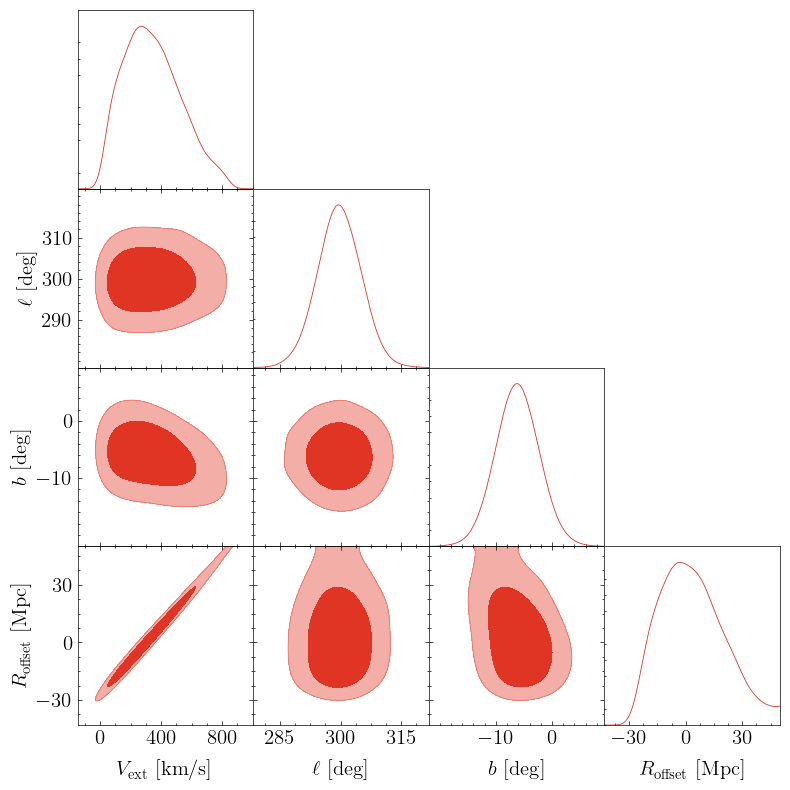

In [36]:
# catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']
catalogue = ['CF4_TFR_w1']
ranges={'rLG': [-50, 50],}
# settings = {'smooth_scale_2D': 0.3, 'smooth_scale_1D': 0.3, 'fine_bins_2D': 1000}
settings = {}

fdir_subfolder = "void_calibrated"
sample_beta = None



X = []
# for simname in ["IndranilVoid_exp", "IndranilVoid_gauss",]:
for simname in ["IndranilVoid_gauss", ]:
    fname = paths.flow_validation(
        fdir, simname, catalogue, inference_method="bayes",
        fdir_subfolder=fdir_subfolder, sample_alpha=False,
        sample_beta=sample_beta, zcmb_max=0.065, remove_CF4_outliers=True)

    samples = get_some_samples(fname, ["rLG", "Vext"] + (["beta"] if sample_beta else []))
    X_i = samples_to_getdist(samples, simname_to_pretty(simname), ranges=ranges, settings=settings)
    X.append(X_i)


# fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_EXPprofileresolution_3501x601_samples.hdf5"
# samples = get_samples(fname, )
# X_i = samples_to_getdist(samples, "Exponential (BF)", settings=settings)
# X.append(X_i)

# fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_GAUSSprofileresolution_3501x601_samples.hdf5"
# samples = get_samples(fname, )
# X_i = samples_to_getdist(samples, "Gauss (BF)", settings=settings)
# X.append(X_i)


params = ["Vmag", "l", "b", "rLG"]
if sample_beta:
    params.append("beta")

with plt.style.context("science"):
    # cols = ['gray', '#009966', '#006FED', '#E03424', '#000866', '#336600', '#006633', 'm', 'r']
    # cols = ['gray', '#009966', '#006FED', '#E03424', '#000866', 'm', 'r', 'm', 'r']
    cols = ['#006FED', '#E03424', '#006FED', '#E03424'][::-1]
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.solid_colors = cols
    g.settings.legend_fontsize = 18
    g.settings.axes_labelsize = 18
    g.settings.axes_fontsize = 18
    g.settings.line_styles = ['-', '-', '--', '--']

    g.triangle_plot(X, params=params, filled=[True, True, False, False],
                    contour_colors=cols,
                    legend_loc='upper right',)
    plt.gcf().tight_layout()
    plt.gcf().show()
    plt.gcf().savefig(f"../../../plots/void_fiducial.pdf", dpi=500, bbox_inches='tight')

#### Predicted void summary statistics

Using h_void = 0.7733393599999999 for profile `exp`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void_calibrated/samples_IndranilVoid_exp_CF4_TFR_w1_bayes_zcmb_max_0.065_sample_beta_remove_CF4_outliers.hdf5
Last modified: 26/03/2025 05:42:14


/mnt/users/rstiskalek/csiborgtools/notebooks/flow/paper_void/../reconstruction_comparison.py:34: RuntimeWarning: invalid value encountered in divide
  dec = np.arcsin(z / d)
/mnt/users/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/tmp/ipykernel_162609/916371498.py:85: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.tight_layout()


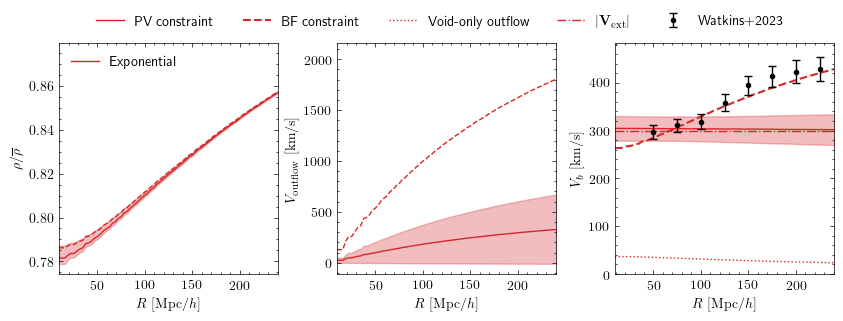

In [ ]:
profiles = ["exp", ]
fdir_subfolder = "void_calibrated"
sample_beta = True
# profiles = ["exp",]


with plt.style.context("science"):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    fig.subplots_adjust(wspace=0.27)
    cols = sns.color_palette()
    cols[0] = "#d62728"
    cols[1] = "#1f77b4"
    lw = plt.rcParams['lines.linewidth']

    for n in range(len(profiles)):
        profile = profiles[n]
        c = cols[n]
        h_void = csiborgtools.flow.select_void_h(100, profile)
        print(f"Using h_void = {h_void} for profile `{profile}`.")

        simname = f"IndranilVoid_{profile}"
        fname = paths.flow_validation(
            fdir, simname, catalogue, inference_method="bayes",
            fdir_subfolder=fdir_subfolder, sample_alpha=False,
            sample_beta=sample_beta, zcmb_max=0.065, remove_CF4_outliers=True)

        r, rho, Vmono, Vbulk, Vbulk_void, Vext, Vmag_l, Vmag_b = read_void_stats_per_sample(fname)
        r = r * h_void

        ylow, ymed, yhigh = np.percentile(rho, [16, 50, 84], axis=0)
        axs[0].plot(r, ymed, color=c, label=simname_to_pretty(simname))
        axs[0].fill_between(r, ylow, yhigh, alpha=0.3, color=c)
        axs[0].set_ylabel(r"$\rho / \overline{\rho}$")

        ylow, ymed, yhigh = np.percentile(Vmono, [16, 50, 84], axis=0)
        axs[1].plot(r, ymed, color=c)
        axs[1].fill_between(r, ylow, yhigh, alpha=0.3, color=c)
        axs[1].set_ylabel(r"$V_{\rm outflow} ~ [\mathrm{km} / \mathrm{s}]$")


        ylow, ymed, yhigh = np.percentile(Vbulk, [16, 50, 84], axis=0)
        axs[2].plot(r, ymed, label="PV constraint" if n == 0 else None,
                    color=c)
        axs[2].fill_between(r, ylow, yhigh, alpha=0.3, color=c)

        if profile != "mb":
            r_bf, rho_bf, vmono_bf, vmag_bf = fiducial_bulk_flow_sergij(profile)

            axs[0].plot(r_bf * h_void, rho_bf, color=c, ls="--")
            axs[1].plot(r_bf * h_void, vmono_bf, color=c, ls="--")

            axs[2].plot(r_bf * h_void, vmag_bf,
                        label="BF constraint" if n == 0 else None,
                        color=c, ls="--", lw=1.5*lw)

        # Void bulk flow only
        ymed = np.nanmedian(Vbulk_void, axis=0)
        axs[2].plot(r, ymed, c=c, ls="dotted", label="Void-only outflow" if n == 0 else None)

        # Vext flow magnitude only
        ymed = np.median(Vext, axis=0)
        axs[2].axhline(ymed, c=c, ls="dashdot", label=r"$|\mathbf{V}_{\rm ext}|$" if n == 0 else None)


    r_over_h_watkins = np.array([50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0])
    bulkflow_watkins =np.array([297.0, 311.0, 318.28218822, 358.20760135, 394.55416487, 413.44319113, 423.37248285, 429.49627515, 432.53804634])
    sigma_1_watkins = np.array([14.0, 14.0, 15.9, 17.5, 19.4, 21.6, 23.7, 25.4, 26.9])
    axs[2].errorbar(r_over_h_watkins, bulkflow_watkins,
                    yerr=sigma_1_watkins, fmt='o', color="black",
                    label="Watkins+2023", ms=3, capsize=3)

    axs[2].set_ylabel(r"$V_b ~ [\mathrm{km} / \mathrm{s}]$")


    ii, jj = np.where(np.isfinite(Vmono[0]))[0][[0, -1]]
    for n in range(3):
        axs[n].set_xlim(r[ii], 240)

    axs[0].legend(loc="upper left")
    axs[2].legend(ncols=5, loc="lower center", bbox_to_anchor=(-0.8, 1.01))

    for ax in axs:
        ax.set_xlabel(r"$R ~ [\mathrm{Mpc} / h]$")

    fig.tight_layout()
    fig.savefig("../../../plots/bulk_flow_fiducial.pdf", dpi=300, bbox_inches='tight')
    fig.show()


File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_mb_CF4_TFR_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 22/03/2025 08:22:13
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_exp_CF4_TFR_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 20/03/2025 19:21:09
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_gauss_CF4_TFR_w1_mike_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 21/03/2025 00:02:28
Removed no burn in


/tmp/ipykernel_162609/1993008225.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


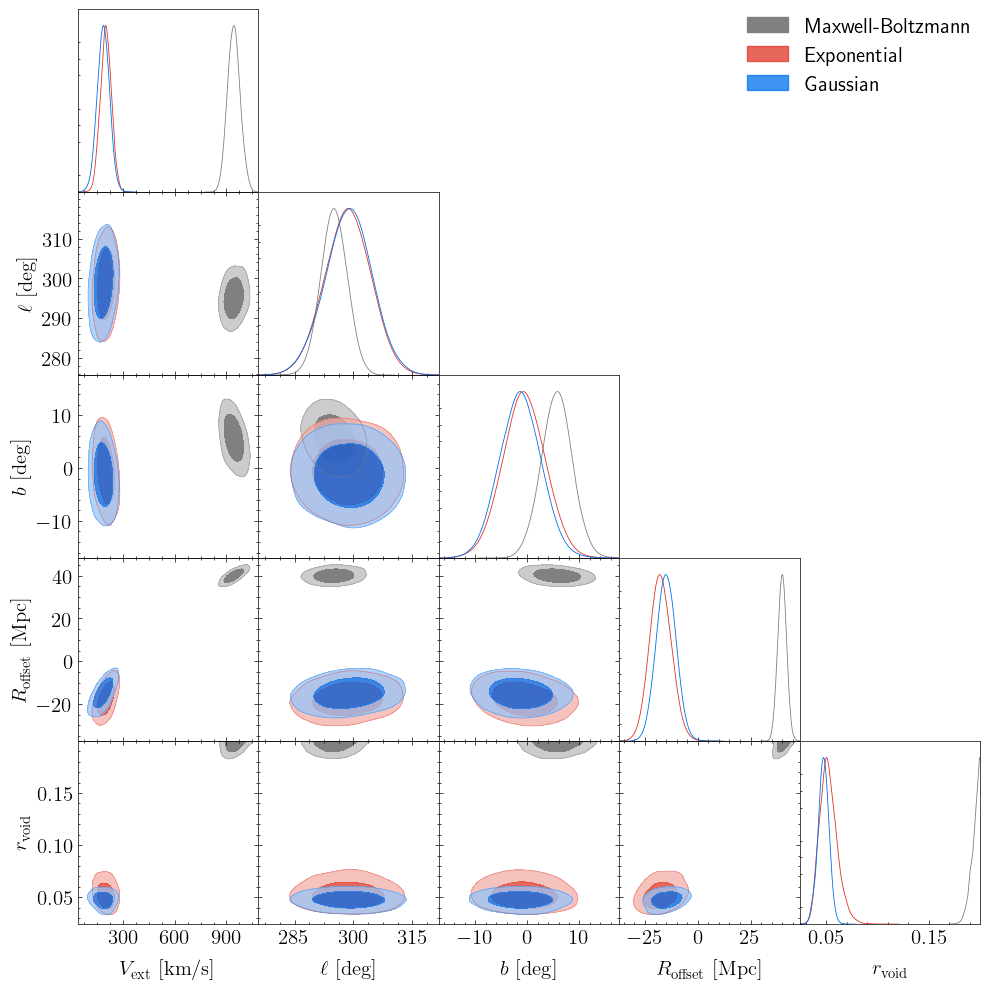

In [48]:
# catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']
catalogue = ['CF4_TFR_w1']

ranges={
    'void_size':[0.01, 0.2],
    # 'void_size':[0.1, 3.0],
    'rLG': [-50, 50],
    }

X = []
for simname in ["IndranilVoidSizeVar_mb", "IndranilVoidSizeVar_exp", "IndranilVoidSizeVar_gauss"]:
    fname = paths.flow_validation(
        fdir, simname, catalogue, fdir_subfolder="void",
        inference_method="mike", sample_alpha=False, sample_beta=None, 
        zcmb_max=0.065, which_void_size_run="zoom", remove_CF4_outliers=True)


    samples = get_some_samples(fname, ["rLG", "Vext", "void_size"])
    X_i = samples_to_getdist(samples, simname_to_pretty(simname), ranges=ranges)
    X.append(X_i)


# params = ["Vmag", "l", "b", "rLG", "void_size"]
with plt.style.context("science"):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 18
    g.settings.axes_labelsize = 18
    g.settings.axes_fontsize = 18

    g.triangle_plot(X, filled=True, legend_loc='upper right')
    plt.gcf().tight_layout()
    plt.gcf().show()
    plt.gcf().savefig(f"../../../plots/void_extended.pdf", dpi=500, bbox_inches='tight')

#### Gaussian plot restricted to large sizes 

#### Void statistics

Using h_void = 0.6917265899999999 for profile `exp`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 17/03/2025 03:16:30


/mnt/users/rstiskalek/csiborgtools/notebooks/flow/paper_void/../reconstruction_comparison.py:34: RuntimeWarning: invalid value encountered in divide
  dec = np.arcsin(z / d)
/mnt/users/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Using h_void = 0.6925296299999999 for profile `gauss`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 17/03/2025 11:09:38
Using h_void = 0.7232258699999999 for profile `mb`.


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_which_void_size_run_coarse_remove_CF4_outliers_stats.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

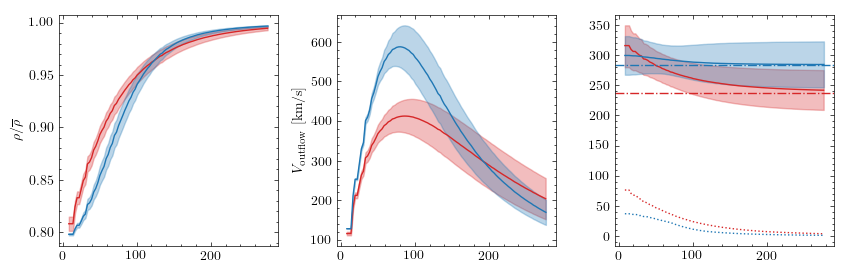

In [ ]:
profiles = ["exp", "gauss", "mb"]
void_size = [6, 6, 300]
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']


with plt.style.context("science"):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    fig.subplots_adjust(wspace=0.27)
    cols = sns.color_palette()
    cols = sns.color_palette()
    cols[0] = "#d62728"
    cols[1] = "#1f77b4"
    lw = plt.rcParams['lines.linewidth']

    for n in range(len(profiles)):
        profile = profiles[n]
        c = cols[n]
        h_void = csiborgtools.flow.select_void_h(void_size[n], profile)
        print(f"Using h_void = {h_void} for profile `{profile}`.")

        simname = f"IndranilVoidSizeVar_{profile}"
        fname = paths.flow_validation(
           fdir, simname, catalogue, fdir_subfolder="void",
           inference_method="bayes", sample_alpha=False, sample_beta=None, 
           zcmb_max=0.065, which_void_size_run="coarse" if profile == "mb" else "zoom",
           remove_CF4_outliers=True)

        r, rho, Vmono, Vbulk, Vbulk_void, Vext, __, __  = read_void_stats_per_sample(fname)
        r = r * h_void

        ylow, ymed, yhigh = np.percentile(rho, [16, 50, 84], axis=0)
        ystd = np.std(rho, axis=0)
        ylow = ymed - ystd
        yhigh = ymed + ystd
        axs[0].plot(r, ymed, color=c, label=simname_to_pretty(simname))
        axs[0].fill_between(r, ylow, yhigh, alpha=0.3, color=c)
        axs[0].set_ylabel(r"$\rho / \overline{\rho}$")

        ylow, ymed, yhigh = np.percentile(Vmono, [16, 50, 84], axis=0)
        ystd = np.std(Vmono, axis=0)
        ylow = ymed - ystd
        yhigh = ymed + ystd
        axs[1].plot(r, ymed, color=c)
        axs[1].fill_between(r, ylow, yhigh, alpha=0.3, color=c)
        axs[1].set_ylabel(r"$V_{\rm outflow} ~ [\mathrm{km} / \mathrm{s}]$")


        ylow, ymed, yhigh = np.percentile(Vbulk, [16, 50, 84], axis=0)
        axs[2].plot(r, ymed, label="PV constraint" if n == 0 else None,
                    color=c)
        axs[2].fill_between(r, ylow, yhigh, alpha=0.3, color=c)

        # Void bulk flow only
        ymed = np.nanmedian(Vbulk_void, axis=0)
        axs[2].plot(r, ymed, c=c, ls="dotted", label="Void-only outflow" if n == 0 else None)

        # Vext flow magnitude only
        ymed = np.median(Vext, axis=0)
        axs[2].axhline(ymed, c=c, ls="dashdot", label=r"$|\mathbf{V}_{\rm ext}|$" if n == 0 else None)


    r_over_h_watkins = np.array([50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0])
    bulkflow_watkins =np.array([297.0, 311.0, 318.28218822, 358.20760135, 394.55416487, 413.44319113, 423.37248285, 429.49627515, 432.53804634])
    sigma_1_watkins = np.array([14.0, 14.0, 15.9, 17.5, 19.4, 21.6, 23.7, 25.4, 26.9])
    axs[2].errorbar(r_over_h_watkins, bulkflow_watkins, yerr=sigma_1_watkins,
                    fmt='o', color="black", label="Watkins+2023", ms=3,
                    capsize=3)

    axs[0].legend()
    axs[2].set_ylim(0)
    axs[2].set_ylabel(r"$V_b ~ [\mathrm{km} / \mathrm{s}]$")

    ii, jj = np.where(np.isfinite(Vmono[0]))[0][[0, -1]]
    for n in range(3):
        axs[n].set_xlim(r[ii], 240)
        axs[n].set_xlabel(r"$R ~ [\mathrm{Mpc} / h]$")

    axs[0].legend(loc="lower right")
    axs[2].legend(ncols=5, loc="lower center", bbox_to_anchor=(-0.8, 1.01))

    fig.tight_layout()
    fig.savefig("../../../plots/bulk_flow_vary_size.pdf", dpi=300)
    fig.show()

### Predited void $H_0$

#### $H_0$ PPD

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 17/03/2025 03:16:30
exp 69.36276 0.3351502
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoidSizeVar_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.065_which_void_size_run_zoom_remove_CF4_outliers.hdf5
Last modified: 17/03/2025 11:09:38
gauss 68.98604 0.1989688


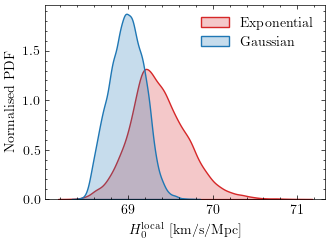

In [90]:
from interpax import Interpolator1D

profiles = ["exp", "gauss",]
cols = ["#d62728", "#1f77b4"]


with plt.style.context("science"):
    plt.figure()

    for n in range(len(profiles)):
        profile = profiles[n]
        simname = f"IndranilVoidSizeVar_{profile}"
        fname = paths.flow_validation(
           fdir, simname, catalogue, fdir_subfolder="void",
           inference_method="bayes", sample_alpha=False, sample_beta=None, 
           zcmb_max=0.065, which_void_size_run="zoom", remove_CF4_outliers=True)

        void_size, h_void = csiborgtools.flow.select_void_h(
            None, profile, return_all=True)

        # Check if the mapping is in H0 or h and sizes in percent
        void_size_to_h_void = Interpolator1D(
            void_size / 100, h_void, method="linear")

        with File(fname, 'r') as f:
            void_size = f["samples/void_size"][...]

        h_void = void_size_to_h_void(void_size)
        print(profile, 100 * h_void.mean(), 100 * h_void.std())

        sns.kdeplot(h_void * 100,
                    label=simname_to_pretty(f"IndranilVoid_{profile}"),
                    fill=True, color=cols[n])

    plt.xlabel(r"$H_0^{\rm local} ~ [\mathrm{km} / \mathrm{s} / \mathrm{Mpc}]$")
    plt.ylabel("Normalised PDF")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../../../plots/h_void_distribution.pdf", dpi=300)
    plt.show()

#### $H_0$ dependence on the void size

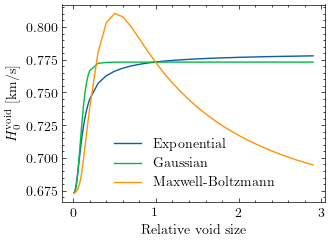

In [49]:
with plt.style.context("science"):
    plt.figure()
    for profile in ["exp", "gauss", "mb"]:
        void_size, h_void = csiborgtools.flow.select_void_h(
                 None, profile, return_all=True)
        m = void_size < 300
        plt.plot(void_size [m]/ 100, h_void[m],
                 label=simname_to_pretty(f"IndranilVoid_{profile}"))
    plt.xlabel("Relative void size")
    plt.ylabel(r"$H_0^{\rm void} ~ [\mathrm{km} / \mathrm{s}]$")
    plt.legend()

    plt.tight_layout()
    # plt.savefig("../../plots/h_void_vs_void_size.png", dpi=300)
    plt.show()


### Evidence comparison

In [46]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']

X = {}
for simname in ["no_field_300",
                "IndranilVoid_exp",
                "IndranilVoid_gauss",
                "IndranilVoid_mb",
                "IndranilVoidSizeVar_exp",
                "IndranilVoidSizeVar_gauss",
                "IndranilVoidSizeVar_mb",
                ]:
    print(simname)

    if "SizeVar" in simname:
        if "_mb" in simname:
            which_void_size_run = "coarse"
        else:
            which_void_size_run = "zoom"
    else:
        which_void_size_run = None


    fname = paths.flow_validation(
        fdir, simname, catalogue, fdir_subfolder="void",
        inference_method="mike",
        sample_alpha=False, sample_beta=None, no_Vext=None,
        zcmb_max=0.065, remove_CF4_outliers=True,
        which_void_size_run=which_void_size_run,
        )

    X[simname] = -get_gof("neg_lnZ_harmonic", fname) / np.log(10)


# for simname in ["Carrick2015", "CF4"]:
#     fname = paths.flow_validation(
#         fdir, simname, catalogue, 
#         inference_method="mike", remove_CF4_outliers=True,
#         sample_alpha=True, sample_beta=None,
#         zcmb_max=0.065)
#     X[simname] = - get_gof("neg_lnZ_harmonic", fname) / np.log(10)

# Take 'IndranilVoid_gass' as a reference
ref = X["no_field_300"]
for key in X:
    X[key] -= ref

# for key in list(X.keys()):
    # val = X.pop(key)
    # X[simname_to_pretty(key)] = round(val, 2)

print()
for key, val in X.items():
    print(f"{key}: {val}")

no_field_300
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_no_field_300_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 23/03/2025 23:59:36
IndranilVoid_exp
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 18/03/2025 15:40:28
IndranilVoid_gauss
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoid_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 18/03/2025 15:33:57
IndranilVoid_mb
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/void/samples_IndranilVoid_mb_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.065_remove_CF4_outliers.hdf5
Last modified: 18/03/2025 14:22:20
IndranilVoidSizeVar_exp
File:          /mnt/extras

#### Evidence dependence on the void size 

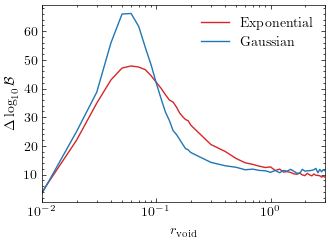

In [101]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']
cols = ["#d62728", "#1f77b4"]

sizes = np.asarray([n for n in range(1, 20)] + [10 * n for n in range(2, 31)])

def void_gof_sizevar(kind, gof):
    y = np.full_like(sizes, np.nan, dtype=float)
    for i, size in enumerate(sizes):
        simname = f"IndranilVoid{size}_{kind}"
        fname = paths.flow_validation(
            fdir, simname, catalogue, fdir_subfolder=None,inference_method="mike",
            sample_alpha=False, sample_beta=None, 
            zcmb_max=0.05, verbose_print=False, )
        if exists(fname):
            y[i] = get_gof(gof, fname)
    return y


logZ = - np.stack([void_gof_sizevar("exp", "neg_lnZ_harmonic"),
                   void_gof_sizevar("gauss", "neg_lnZ_harmonic"),])
logZ /= np.log(10)
logZ -= ref

sizes = sizes / 100

logZ[0][14] = np.nan

m = np.isfinite(logZ[0])
from scipy.interpolate import interp1d
logZ[0, ~m] = interp1d(sizes[m], logZ[0, m], kind="cubic")(sizes[~m])


with plt.style.context("science"):
    plt.figure()
    m = sizes > 0
    plt.plot(sizes[m], logZ[0][m],
             label=simname_to_pretty("IndranilVoid_exp"), c=cols[0])
    plt.plot(sizes[m], logZ[1][m],
             label=simname_to_pretty("IndranilVoid_gauss"), c=cols[1])

    plt.xlim(sizes.min(), sizes.max())
    plt.xlabel(r"$r_{\rm void}$")
    plt.ylabel(r"$\Delta \log_{10} \mathcal{B}$")
    plt.legend()
    plt.xscale("log")

    plt.tight_layout()
    plt.savefig("../../../plots/void_size_var.pdf", dpi=300)
    plt.show()



### Extended analysis, varying the void size and $\beta$

#### Corner plot

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_exp_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05_sample_beta_which_void_size_run_zoom.hdf5
Last modified: 19/12/2024 15:27:59
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_gauss_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05_sample_beta_which_void_size_run_zoom.hdf5
Last modified: 19/12/2024 13:08:11
Removed no burn in


/tmp/ipykernel_1947110/1037148779.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


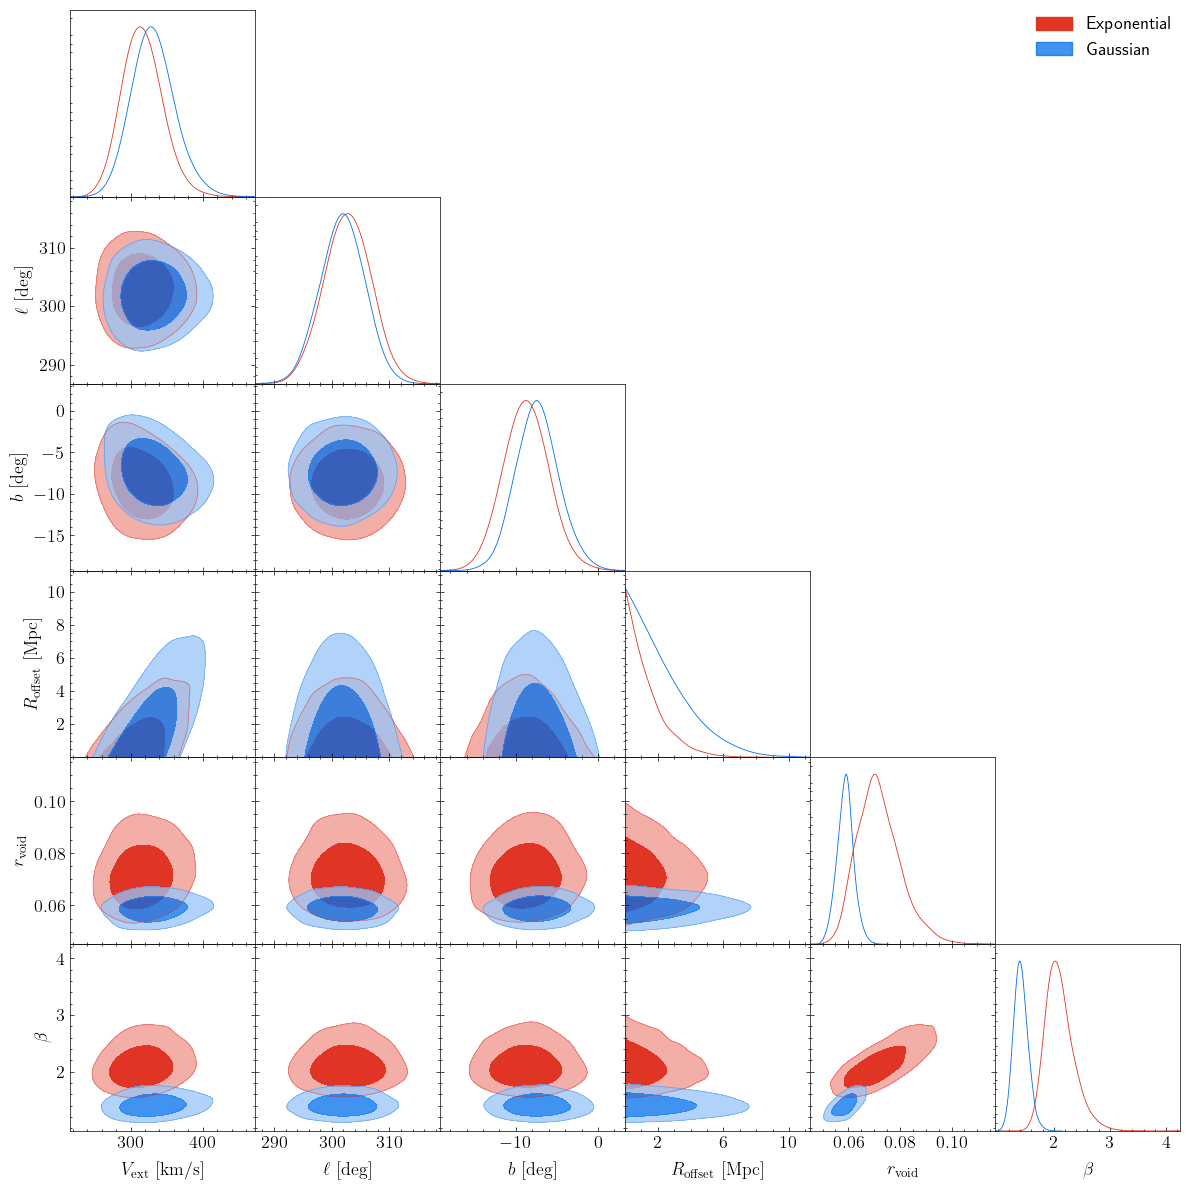

In [ ]:
catalogue = ['LOSS', 'Foundation', 'CF4_TFR_i', 'CF4_TFR_notSDSS_w1']

ranges={
    'void_size':[0.01, 0.2],
    # 'void_size':[0.1, 3.0],
    'rLG': [0, 50],
    }

X = []
for simname in ["IndranilVoidSizeVar_exp", "IndranilVoidSizeVar_gauss"]:
    fname = paths.flow_validation(
        fdir, simname, catalogue, inference_method="mike",
        sample_alpha=False, sample_beta=True,
        zcmb_max=0.05, which_void_size_run="zoom")

    X_i = samples_to_getdist(get_samples(fname, True), simname_to_pretty(simname.replace("SizeVar", "")), ranges=ranges)
    X.append(X_i)


params = ["Vmag", "l", "b", "rLG", "void_size", "beta"]
with plt.style.context("science"):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 16
    g.settings.axes_labelsize = 16
    g.settings.axes_fontsize = 16

    g.triangle_plot(X, params=params, filled=True, legend_loc='upper right')
    plt.gcf().tight_layout()
    plt.gcf().show()
    plt.gcf().savefig(f"../../plots/void_extended_with_beta.pdf", dpi=500, bbox_inches='tight')